## 1. Data Loading

In [29]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

air_quality= fetch_ucirepo(id=360)
data = air_quality.data.features

print(f"Dataset shape: {data.shape}")
print(f"Column names:")
print(data.columns.tolist())

Dataset shape: (9357, 15)
Column names:
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


## 2. Data Processing

### Step 1: DateTime Consolidation

Merge the separate Date and Time columns into a single DateTime column and set it as the index for time series analysis. Note that the actual date range spans from March 2004 to April 2005, which differs from the project description.

In [30]:
# Merge Date and Time columns
data['DateTime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='mixed')

# Drop original Date and Time columns
data = data.drop(['Date', 'Time'], axis=1)

# Set DateTime as index
data = data.set_index('DateTime')

print("Date range:")
print(f"Start: {data.index.min()}")
print(f"End: {data.index.max()}")
print(f"Total duration: {data.index.max() - data.index.min()}")

Date range:
Start: 2004-03-10 18:00:00
End: 2005-04-04 14:00:00
Total duration: 389 days 20:00:00


### Step 2: Missing Value Imputation

Handle missing values (represented as -200) through linear interpolation. Note that NMHC(GT) contains an excessive number of missing values (8443 out of 9357), rendering it practically unusable for analysis.

The interpolation preserves original data types to maintain consistency throughout the dataset.

In [31]:

# Check missing values (-200) before processing
print("Missing values count (-200):")
missing_counts = (data == -200.0).sum()
print(missing_counts)
print(f"\nTotal missing values: {missing_counts.sum()}")

# Store original data types before interpolation
original_dtypes = data.dtypes.copy()

# Replace -200 with NaN
data = data.replace(-200.0, np.nan)

# Interpolate missing values using linear interpolation
data = data.interpolate(method='linear', limit_direction='both')

# Restore original data types (convert int columns back to int)
for col in data.columns:
    if original_dtypes[col] in ['int64', 'int32', 'int16', 'int8']:
        data[col] = data[col].round().astype(original_dtypes[col])

Missing values count (-200):
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

Total missing values: 16701


### Step 3: Temporal Feature Engineering

Extract temporal features from the DateTime index, including hour of day, day of week, and month. These features enable the model to capture temporal patterns in air quality measurements.

In [32]:
# Extract time-based features from DateTime index
data['Hour'] = data.index.hour
data['Weekday'] = data.index.dayofweek  # Monday=0, Sunday=6
data['Month'] = data.index.month

## 3. Exploratory Data Analysis

### 3.1 Temporal Trends

Visualize the temporal trends of ground truth (GT) pollutant measurements over time. The daily aggregated values reveal a clear seasonal pattern, with higher pollution levels observed during winter months.

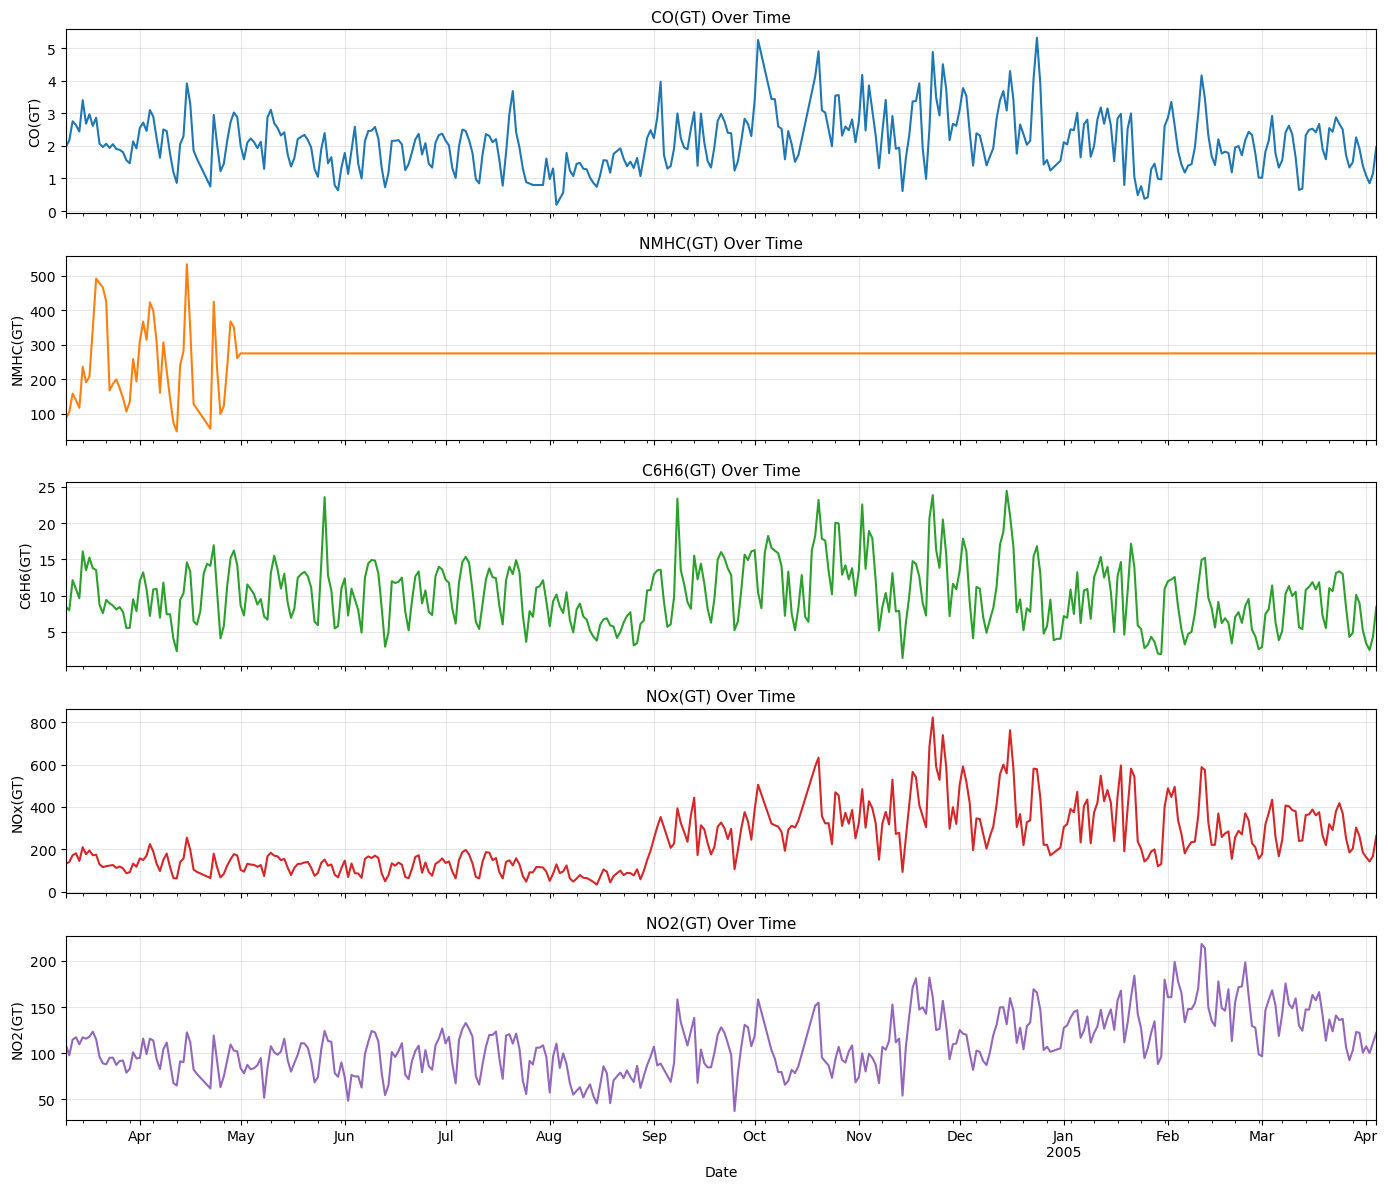

In [33]:
# Select all GT columns
gt_columns = [col for col in data.columns if 'GT' in col]

# Create subplots for each GT column
fig, axes = plt.subplots(len(gt_columns), 1, figsize=(14, 12), sharex=True)

for idx, col in enumerate(gt_columns):
    data[col].resample('D').mean().plot(ax=axes[idx], color=f'C{idx}', linewidth=1.5)
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_title(f'{col} Over Time', fontsize=11)

axes[-1].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.show()

### 3.2 Pollutant Correlations

Analyze the correlation structure among different pollutant measurements. The results show strong positive correlations (> 0.5) between CO, C6H6, NOx, and NO2, suggesting common emission sources or atmospheric chemistry. However, NMHC exhibits problematic correlation patterns due to the excessive missing values mentioned previously.

In [34]:
pollutants = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
data[pollutants].corr()

,CO(GT),NMHC(GT),C6H6(GT),NOx(GT),NO2(GT)
CO(GT),1.000000,0.267501,0.816518,0.791269,0.675795
NMHC(GT),0.267501,1.000000,0.233381,0.141745,0.186728
C6H6(GT),0.816518,0.233381,1.000000,0.655010,0.570252
NOx(GT),0.791269,0.141745,0.655010,1.000000,0.763039
NO2(GT),0.675795,0.186728,0.570252,0.763039,1.000000


### 3.3 Meteorological-Chemical Relationships

Examine the relationships between meteorological variables (Temperature, Relative Humidity, Absolute Humidity) and pollutant concentrations. Key observations include:
- C6H6 shows positive correlation with temperature
- NOx and NO2 exhibit negative correlation with temperature
- NOx demonstrates positive correlation with relative humidity
- NO2 shows strong negative correlation with absolute humidity

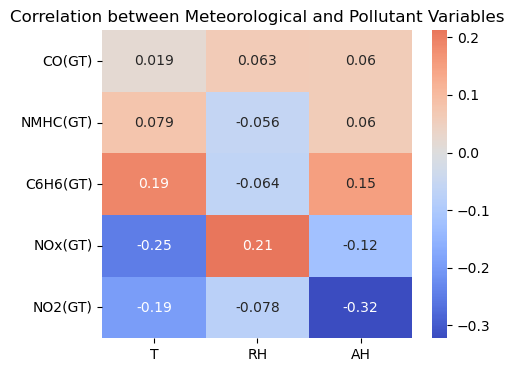

In [35]:
pollutants = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
meteo = ['T', 'RH', 'AH']

corr = data[pollutants + meteo].corr()
corr_meteo = corr.loc[pollutants, meteo]

plt.figure(figsize=(5,4))
sns.heatmap(corr_meteo, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation between Meteorological and Pollutant Variables")
plt.show()

## 4. Train-Test-Validation Split

Split the processed dataset into training, test, and validation sets based on temporal order:
- Training set: 2004 data
- Test set: 2005 data until February 28
- Validation set: 2005 data after February 28

This temporal split ensures chronological separation between training, test, and validation data.

In [36]:
# Split data by temporal order (using .copy() to avoid SettingWithCopyWarning)
train_data = data[data.index.year == 2004].copy()
test_data = data[(data.index.year == 2005) & (data.index < '2005-03-01')].copy()
val_data = data[data.index >= '2005-03-01'].copy()

print(f"Training data (2004):")
print(f"  - Shape: {train_data.shape}")
print(f"  - Date range: {train_data.index.min()} to {train_data.index.max()}")

print(f"\nTest data (2005 until Feb 28):")
print(f"  - Shape: {test_data.shape}")
print(f"  - Date range: {test_data.index.min()} to {test_data.index.max()}")

print(f"\nValidation data (after Feb 28, 2005):")
print(f"  - Shape: {val_data.shape}")
print(f"  - Date range: {val_data.index.min()} to {val_data.index.max()}")

Training data (2004):
  - Shape: (7110, 16)
  - Date range: 2004-03-10 18:00:00 to 2004-12-31 23:00:00

Test data (2005 until Feb 28):
  - Shape: (1416, 16)
  - Date range: 2005-01-01 00:00:00 to 2005-02-28 23:00:00

Validation data (after Feb 28, 2005):
  - Shape: (831, 16)
  - Date range: 2005-03-01 00:00:00 to 2005-04-04 14:00:00


## 5. Feature Normalization

Normalize continuous features (float columns) using StandardScaler fitted on training data only. This prevents data leakage by ensuring test and validation set statistics don't influence the normalization. The same transformation (using training set statistics) is then applied to training, test, and validation sets.

In [37]:
# Identify float columns to normalize
float_columns = train_data.select_dtypes(include=['float64', 'float32', 'float16']).columns.tolist()
int_columns = train_data.select_dtypes(include=['int64', 'int32', 'int16', 'int8']).columns.tolist()

# Fit StandardScaler on training data only
scaler = StandardScaler()
scaler.fit(train_data[float_columns])

# Transform train, test, and validation data using training statistics
train_data[float_columns] = scaler.transform(train_data[float_columns])
test_data[float_columns] = scaler.transform(test_data[float_columns])
val_data[float_columns] = scaler.transform(val_data[float_columns])

## 6. Export Processed Data

Save the normalized training, test, and validation datasets to separate CSV files for subsequent analysis and modeling.


In [38]:
# Export to separate CSV files
train_data.to_csv('cleaned_features_train.csv')
test_data.to_csv('cleaned_features_test.csv')
val_data.to_csv('cleaned_features_val.csv')

print(f"Training data (2004) saved: cleaned_features_train.csv")
print(f"  - Shape: {train_data.shape}")
print(f"  - Date range: {train_data.index.min()} to {train_data.index.max()}")

print(f"\nTest data (2005 until Feb 28) saved: cleaned_features_test.csv")
print(f"  - Shape: {test_data.shape}")
print(f"  - Date range: {test_data.index.min()} to {test_data.index.max()}")

print(f"\nValidation data (after Feb 28, 2005) saved: cleaned_features_val.csv")
print(f"  - Shape: {val_data.shape}")
print(f"  - Date range: {val_data.index.min()} to {val_data.index.max()}")


Training data (2004) saved: cleaned_features_train.csv
  - Shape: (7110, 16)
  - Date range: 2004-03-10 18:00:00 to 2004-12-31 23:00:00

Test data (2005 until Feb 28) saved: cleaned_features_test.csv
  - Shape: (1416, 16)
  - Date range: 2005-01-01 00:00:00 to 2005-02-28 23:00:00

Validation data (after Feb 28, 2005) saved: cleaned_features_val.csv
  - Shape: (831, 16)
  - Date range: 2005-03-01 00:00:00 to 2005-04-04 14:00:00
